In [100]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Extracting the Data


In [106]:
import os
import pandas as pd

data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/forecasting"
energy_data = os.path.join(data_path, "energy_dataset.csv")
energy_data = pd.read_csv(energy_data)
energy_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [107]:
energy_data.shape

(35064, 29)

In [108]:
energy_data.columns

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')

## Merge weather features to the dataset

In [109]:
weather_ft = os.path.join(data_path, "weather_features.csv")
weather_ft = pd.read_csv(weather_ft)
weather_ft.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [110]:
weather_ft = weather_ft[weather_ft['city_name'] == 'Madrid']
weather_ft.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
35145,2015-01-01 00:00:00+01:00,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
35146,2015-01-01 01:00:00+01:00,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
35147,2015-01-01 02:00:00+01:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
35148,2015-01-01 03:00:00+01:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
35149,2015-01-01 04:00:00+01:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [111]:
energy_data['time'] = pd.to_datetime(energy_data['time'])
energy_data = energy_data.set_index('time')

In [112]:
weather_ft['dt_iso'] = pd.to_datetime(weather_ft['dt_iso'])
weather_ft = weather_ft.set_index('dt_iso')

In [120]:
weather_ft

,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
dt_iso,,,,,,,,,,,,,,,,
2015-01-01 00:00:00+01:00,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 01:00:00+01:00,Madrid,267.325,267.325,267.325,971,63,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 02:00:00+01:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 03:00:00+01:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 04:00:00+01:00,Madrid,266.186,266.186,266.186,971,64,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00+01:00,Madrid,283.560,282.150,285.150,1030,88,1,280,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2018-12-31 20:00:00+01:00,Madrid,280.120,278.150,281.150,1031,52,1,260,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2018-12-31 21:00:00+01:00,Madrid,278.150,278.150,278.150,1030,65,1,340,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [121]:

weather_ft.index.is_unique

False

In [122]:
energy_data.index.is_unique

True

In [123]:
energy_data[energy_data.index.duplicated()]

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,


In [124]:
energy_data = energy_data[~energy_data.index.duplicated()]
weather_ft = weather_ft[~weather_ft.index.duplicated()]

In [125]:
energy_data = pd.concat([energy_data, weather_ft], axis=1)

In [126]:
energy_data.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,1,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,1,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n


# Data Visualization

In [134]:
energy_data['time'] = energy_data.index

In [137]:
energy_data.drop(columns='city_name', inplace=True)

> Drop city names column since we are only testing the city of Mardrid

## Monthly

In [138]:
vis_df = energy_data.copy()
vis_df.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon,time
2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 00:00:00+01:00
2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 01:00:00+01:00
2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 02:00:00+01:00
2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 03:00:00+01:00
2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 04:00:00+01:00


In [140]:
vis_df['time'] = pd.to_datetime(vis_df['time'], utc=True)
vis_df_monthly = (
    vis_df
    .set_index('time')
    .resample('ME')
    .agg({
        **{col: 'mean' for col in vis_df.select_dtypes(include='number').columns},
        'weather_description': lambda x: x.mode()[0] if not x.mode().empty else None
    })
    .reset_index()
)

vis_df_monthly.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_description
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,971.000000,63.000000,1.000000,309.000000,0.000000,0.000000,0.0,0.000000,800.000000,sky is clear
1,2015-01-31 00:00:00+00:00,483.716235,572.843111,0.0,4849.984993,5411.347885,306.030014,0.0,0.0,0.0,...,968.702957,75.825269,2.184140,204.688172,0.034677,0.000000,0.0,22.033602,774.923387,sky is clear
2,2015-02-28 00:00:00+00:00,470.226190,313.416667,0.0,4675.349702,4047.590774,319.404762,0.0,0.0,0.0,...,955.790179,75.665179,3.632440,215.153274,0.043750,0.000000,0.0,36.165179,771.901786,sky is clear
3,2015-03-31 00:00:00+00:00,468.071237,244.405914,0.0,4615.216398,4236.115591,319.208333,0.0,0.0,0.0,...,1009.813172,69.059140,2.477151,164.310484,0.180242,0.000847,0.0,27.262097,724.506720,sky is clear
4,2015-04-30 00:00:00+00:00,426.409471,463.247911,0.0,4952.200557,4819.632312,338.793872,0.0,0.0,0.0,...,1001.419444,63.658333,2.922222,160.241667,0.117083,0.001383,0.0,32.681944,725.106944,sky is clear


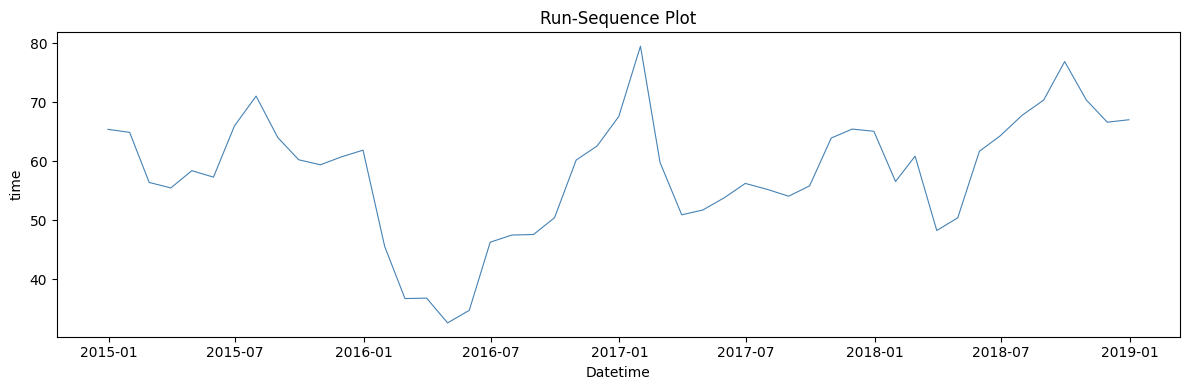

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(vis_df_monthly.time, vis_df_monthly['price actual'],
         linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel(vis_df_monthly.columns[0])
plt.tight_layout()
plt.show()

## Daily

In [142]:
vis_df = energy_data.copy()
vis_df.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon,time
2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 00:00:00+01:00
2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,309,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 01:00:00+01:00
2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 02:00:00+01:00
2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 03:00:00+01:00
2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,273,0.0,0.0,0.0,0,800,clear,sky is clear,01n,2015-01-01 04:00:00+01:00


In [144]:
vis_df['time'] = pd.to_datetime(vis_df['time'], utc=True)
vis_df_daily = (
    vis_df
    .set_index('time')
    .resample('D')
    .agg({
        **{col: 'mean' for col in vis_df.select_dtypes(include='number').columns},
        'weather_description': lambda x: x.mode()[0] if not x.mode().empty else None
    })
    .reset_index()
)

vis_df_daily.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_description
0,2014-12-31 00:00:00+00:00,447.000000,329.000000,0.0,4844.000000,4821.000000,162.000000,0.0,0.0,0.0,...,971.000000,63.000000,1.000000,309.000000,0.0,0.0,0.0,0.000000,800.000000,sky is clear
1,2015-01-01 00:00:00+00:00,425.208333,243.708333,0.0,4187.791667,4099.458333,161.500000,0.0,0.0,0.0,...,988.500000,62.583333,0.875000,234.250000,0.0,0.0,0.0,0.000000,800.000000,sky is clear
2,2015-01-02 00:00:00+00:00,389.875000,0.000000,0.0,3566.166667,1258.125000,200.833333,0.0,0.0,0.0,...,992.250000,64.583333,1.000000,219.208333,0.0,0.0,0.0,5.291667,800.208333,sky is clear
3,2015-01-03 00:00:00+00:00,436.875000,0.000000,0.0,3451.791667,1375.958333,229.791667,0.0,0.0,0.0,...,981.125000,66.250000,0.958333,144.375000,0.0,0.0,0.0,0.000000,800.000000,sky is clear
4,2015-01-04 00:00:00+00:00,396.375000,13.583333,0.0,3526.125000,2315.291667,356.625000,0.0,0.0,0.0,...,974.208333,67.416667,0.958333,99.541667,0.0,0.0,0.0,0.000000,800.000000,sky is clear


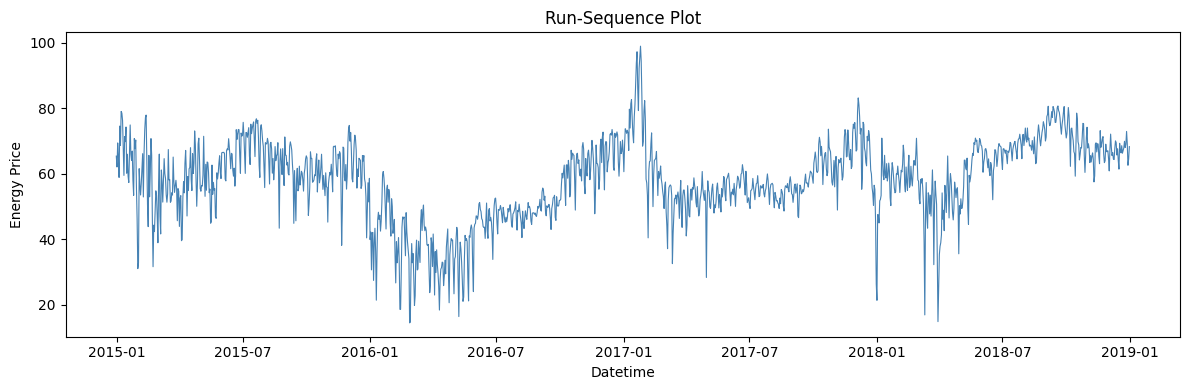

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(vis_df_daily.time, vis_df_daily['price actual'],
         linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel("Energy Price")
plt.tight_layout()
plt.show()

In [154]:
energy_data = vis_df_daily

# Transforming the data

## Checking for Null values in the dataset

In [155]:
print(energy_data['price actual'].isnull().sum())

0


In [156]:
# checking for log transforms

print(f"Min price: {energy_data['price actual'].min()}")
print(f"Zeros: {(energy_data['price actual'] == 0).sum()}")
print(f"Negatives: {(energy_data['price actual'] < 0).sum()}")

Min price: 14.514583333333334
Zeros: 0
Negatives: 0


## Stationarity Data testing

In [157]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test: p < 0.05 means stationary
result = adfuller(energy_data['price actual'])
print(f"ADF p-value: {result[1]}")

# KPSS Test: p > 0.05 means stationary
result = kpss(energy_data['price actual'], regression='c')
print(f"KPSS p-value: {result[1]}")

ADF p-value: 0.050206376969170984
KPSS p-value: 0.01


> The data is not stationary due to the p-value of ADF is less than 0.05 and the KPSS p-value is not greater than 0.05

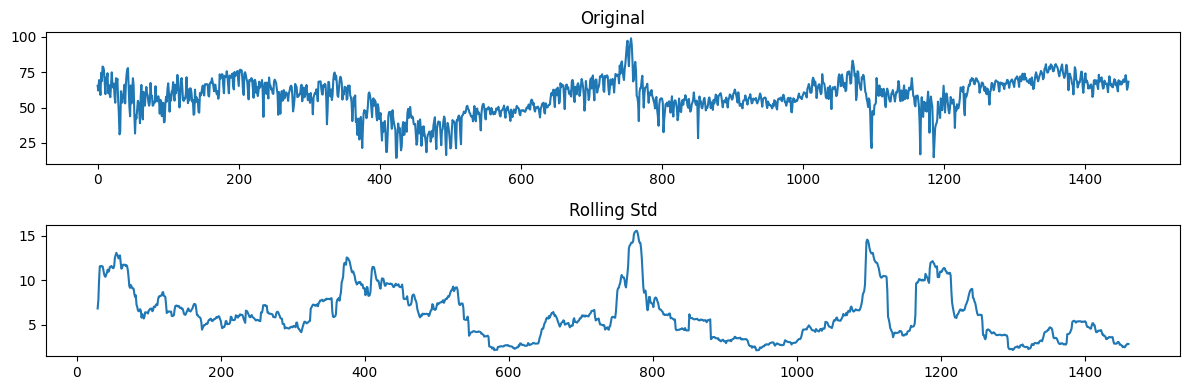

In [158]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
energy_data['price actual'].plot(ax=axes[0], title="Original")
energy_data['price actual'].rolling(30).std().plot(ax=axes[1], title='Rolling Std')
plt.tight_layout()
plt.show()

count    1462.000000
mean       57.889254
std        12.067136
min        14.514583
25%        50.828854
50%        58.602292
75%        66.510000
max        98.982917
Name: price actual, dtype: float64


<Axes: >

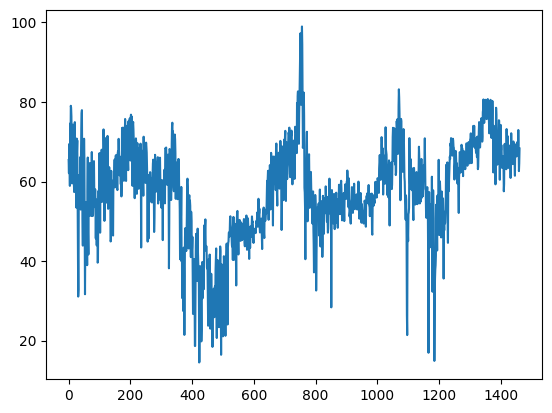

In [159]:

print(energy_data['price actual'].describe())
energy_data['price actual'].plot()

In [160]:
import numpy as np
energy_data['price_transformed'] = np.log(energy_data['price actual'])

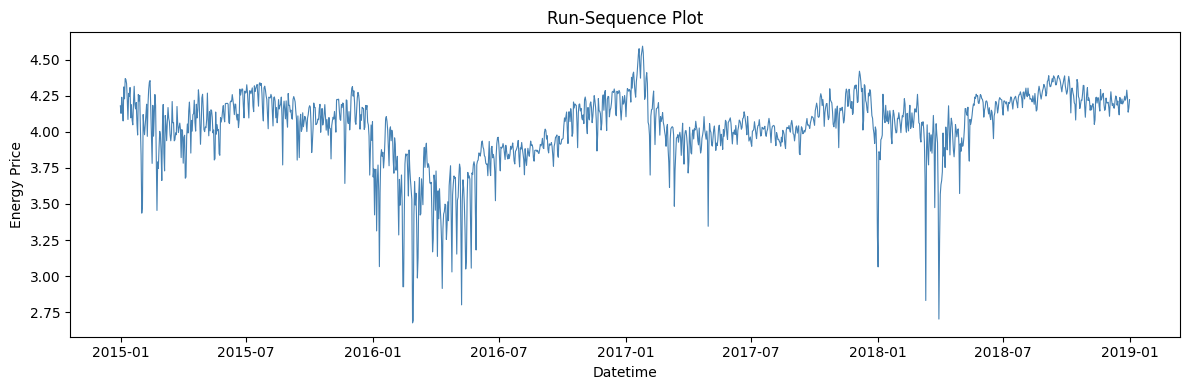

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(energy_data.time, energy_data['price_transformed'],
         linewidth=0.8, color='steelblue')

plt.title("Run-Sequence Plot")
plt.xlabel("Datetime")
plt.ylabel("Energy Price")
plt.tight_layout()
plt.show()

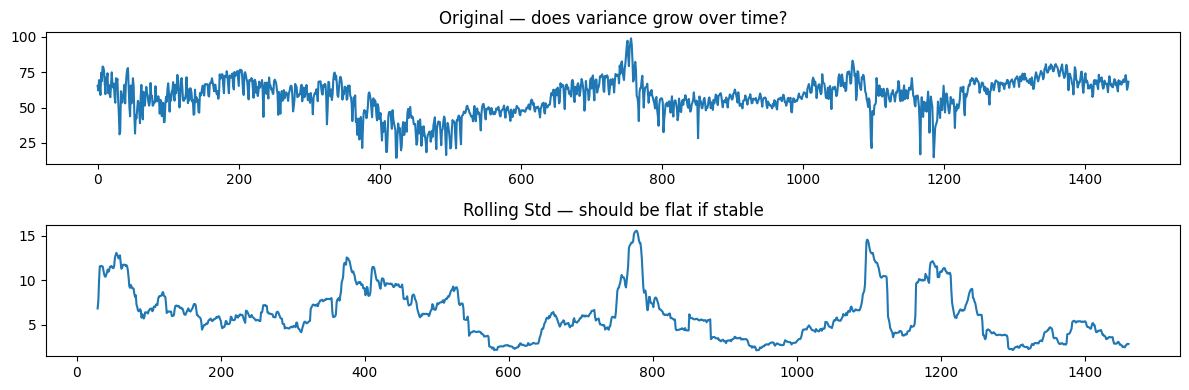

In [162]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
energy_data['price actual'].plot(ax=axes[0], title='Original — does variance grow over time?')
energy_data['price actual'].rolling(30).std().plot(ax=axes[1], title='Rolling Std — should be flat if stable')
plt.tight_layout()
plt.show()

## Checking for outliers

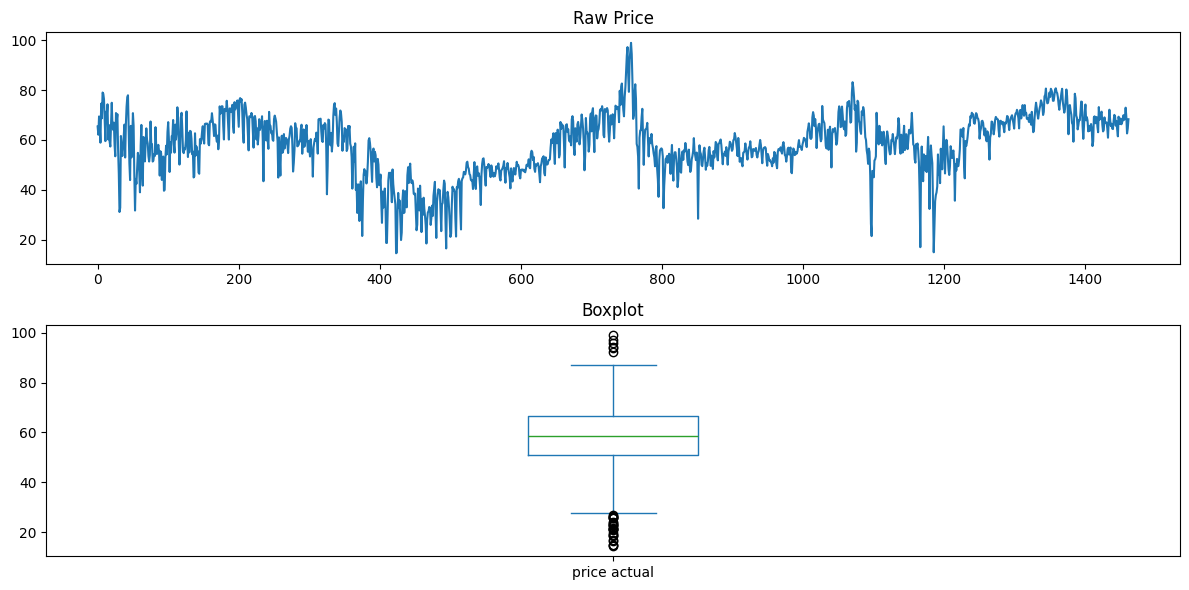

Outliers found: 0 rows (0.00%)
Empty DataFrame
Columns: [time, generation biomass, generation fossil brown coal/lignite, generation fossil coal-derived gas, generation fossil gas, generation fossil hard coal, generation fossil oil, generation fossil oil shale, generation fossil peat, generation geothermal, generation hydro pumped storage aggregated, generation hydro pumped storage consumption, generation hydro run-of-river and poundage, generation hydro water reservoir, generation marine, generation nuclear, generation other, generation other renewable, generation solar, generation waste, generation wind offshore, generation wind onshore, forecast solar day ahead, forecast wind offshore eday ahead, forecast wind onshore day ahead, total load forecast, total load actual, price day ahead, price actual, temp, temp_min, temp_max, pressure, humidity, wind_speed, wind_deg, rain_1h, rain_3h, snow_3h, clouds_all, weather_id, weather_description, price_transformed]
Index: []

[0 rows x 43 colum

In [163]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Raw series
energy_data['price actual'].plot(ax=axes[0], title='Raw Price')

# Boxplot to see outlier distribution
energy_data['price actual'].plot(kind='box', ax=axes[1], title='Boxplot')
plt.tight_layout()
plt.show()

# Also check how many outliers exist
Q1 = energy_data['price actual'].quantile(0.25)
Q3 = energy_data['price actual'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = energy_data[(energy_data['price actual'] < lower) |
                        (energy_data['price actual'] > upper)]
print(f"Outliers found: {len(outliers)} rows ({len(outliers)/len(energy_data)*100:.2f}%)")
print(outliers)

In [164]:
energy_data['time'] = pd.to_datetime(energy_data['time'])
energy_data = energy_data.set_index('time')

print(energy_data.index)

DatetimeIndex(['2014-12-31 00:00:00+00:00', '2015-01-01 00:00:00+00:00',
               '2015-01-02 00:00:00+00:00', '2015-01-03 00:00:00+00:00',
               '2015-01-04 00:00:00+00:00', '2015-01-05 00:00:00+00:00',
               '2015-01-06 00:00:00+00:00', '2015-01-07 00:00:00+00:00',
               '2015-01-08 00:00:00+00:00', '2015-01-09 00:00:00+00:00',
               ...
               '2018-12-22 00:00:00+00:00', '2018-12-23 00:00:00+00:00',
               '2018-12-24 00:00:00+00:00', '2018-12-25 00:00:00+00:00',
               '2018-12-26 00:00:00+00:00', '2018-12-27 00:00:00+00:00',
               '2018-12-28 00:00:00+00:00', '2018-12-29 00:00:00+00:00',
               '2018-12-30 00:00:00+00:00', '2018-12-31 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='time', length=1462, freq=None)


# ARIMA

## Train - Test Split

In [165]:

# 80% train 20% validation
split_index = int(len(energy_data) * 0.80)

train = energy_data.iloc[:split_index]
test  = energy_data.iloc[split_index:]

print(f"Total observations : {len(energy_data)}")
print(f"Train size: {len(train)} ({len(train)/len(energy_data)*100:.2f}%)")
print(f"Test size: {len(test)}  ({len(test)/len(energy_data)*100:.2f}%)")
print(f"\nTrain period: {train.index[0]} → {train.index[-1]}")
print(f"Test period : {test.index[0]} → {test.index[-1]}")

Total observations : 1462
Train size: 1169 (79.96%)
Test size: 293  (20.04%)

Train period: 2014-12-31 00:00:00+00:00 → 2018-03-13 00:00:00+00:00
Test period : 2018-03-14 00:00:00+00:00 → 2018-12-31 00:00:00+00:00


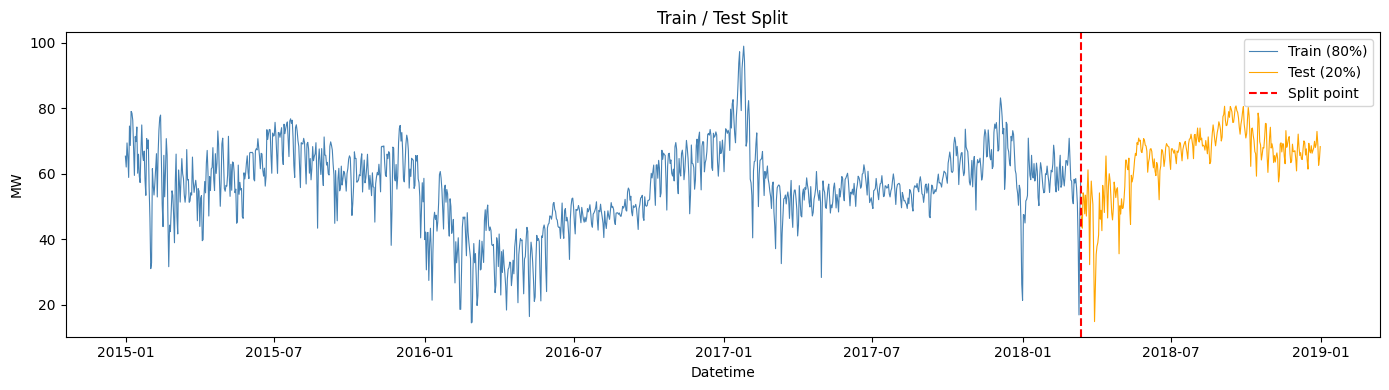

In [166]:

plt.figure(figsize=(14, 4))
plt.plot(train.index, train['price actual'], label="Train (80%)", color="steelblue", linewidth=0.8)
plt.plot(test.index,  test['price actual'],  label="Test (20%)",  color="orange",    linewidth=0.8)
plt.axvline(x=test.index[0], color="red", linestyle="--", label="Split point")
plt.title("Train / Test Split")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

### PACF and ACF

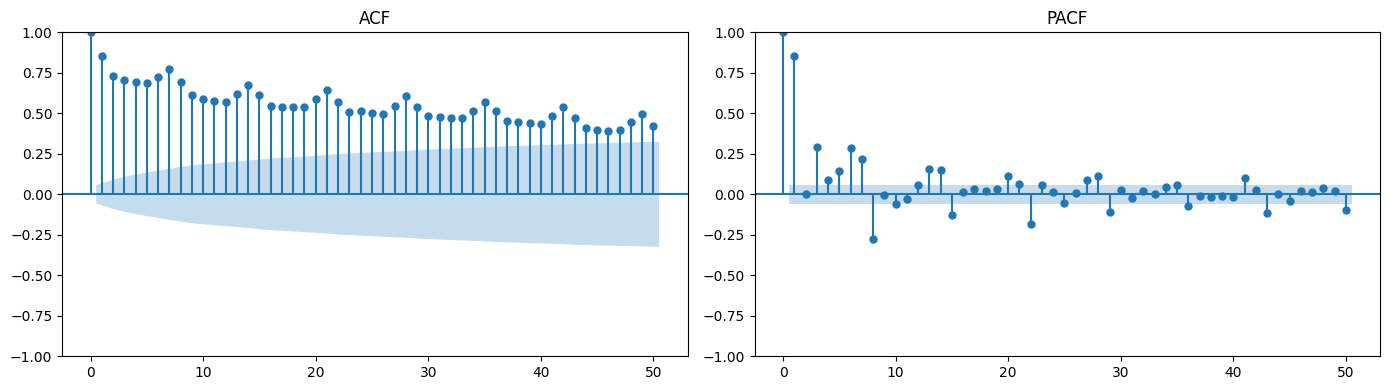

In [167]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(train['price actual'].dropna(),  lags=50, ax=axes[0])
plot_pacf(train['price actual'].dropna(), lags=50, method='ywm', ax=axes[1])

axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

## Model Training

In [168]:
import itertools
import warnings
import statsmodels.api as sm
warnings.filterwarnings("ignore")

p_range = range(0, 4)
d_range = [0]
q_range = range(0, 4)

aic_results = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = sm.tsa.ARIMA(train['price actual'], order=(p, d, q)).fit()
        aic_results.append({"p": p, "d": d, "q": q, "AIC": round(model.aic, 2)})
    except:
        continue

aic_df = pd.DataFrame(aic_results).sort_values("AIC")
print(aic_df.head(10))

best = aic_df.iloc[0]
optimal_p, optimal_d, optimal_q = int(best.p), int(best.d), int(best.q)
print(f"\nOptimal Order: ARIMA({optimal_p}, {optimal_d}, {optimal_q})")

    p  d  q      AIC
15  3  0  3  7385.19
6   1  0  2  7401.65
7   1  0  3  7401.95
10  2  0  2  7402.15
14  3  0  2  7402.25
11  2  0  3  7403.84
13  3  0  1  7405.03
12  3  0  0  7473.77
9   2  0  1  7551.17
4   1  0  0  7579.89

Optimal Order: ARIMA(3, 0, 3)


In [169]:
arima_model = sm.tsa.ARIMA(
    train['price actual'],
    order=(optimal_p, optimal_d, optimal_q)
).fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:           price actual   No. Observations:                 1169
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -3684.593
Date:                Wed, 15 Apr 2026   AIC                           7385.187
Time:                        14:26:00   BIC                           7425.698
Sample:                    12-31-2014   HQIC                          7400.467
                         - 03-13-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.1010      2.413     23.250      0.000      51.372      60.830
ar.L1          2.0151      0.047     43.058      0.000       1.923       2.107
ar.L2         -1.6134      0.082    -19.754      0.0

In [170]:
arima_pred_obj = arima_model.apply(test['price actual']).get_prediction(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)
arima_preds = arima_pred_obj.predicted_mean

arima_preds.index = test.index


In [171]:
arima_model.save('arima_model.pkl')

In [172]:
import joblib

joblib.dump({
    'optimal_p': optimal_p,
    'optimal_d': optimal_d,
    'optimal_q': optimal_q,
}, 'arima_params.joblib')

# Load
params = joblib.load('arima_params.joblib')

## Metrics and Visualization

### MSE

In [173]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Grid search over window sizes
windows = range(2, 49)  # test windows 2–48
results = []

for w in windows:
    # Rolling mean on train, predict on test
    preds = energy_data['price actual'].shift(1).rolling(w).mean().iloc[split_index:]
    actuals = test['price actual']

    # Align (drop NaNs)
    mask = preds.notna()
    rmse = np.sqrt(mean_squared_error(actuals[mask], preds[mask]))
    results.append({"window": w, "rmse": rmse})

results_df = pd.DataFrame(results)
optimal_window = results_df.loc[results_df.rmse.idxmin(), "window"]
print(results_df.sort_values("rmse").head(10))
print(f"\nOptimal Window: {optimal_window}")

   window      rmse
5       7  5.289253
4       6  5.335230
0       2  5.351039
6       8  5.351173
2       4  5.354944
3       5  5.373912
1       3  5.402442
7       9  5.418604
8      10  5.513486
9      11  5.630576

Optimal Window: 7


In [174]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def get_metrics(actuals, preds, model_name):
    mae  = mean_absolute_error(actuals, preds)
    rmse = mean_squared_error(actuals, preds)
    mask = actuals.values != 0
    mape = np.mean(np.abs((actuals.values[mask] - preds.values[mask]) /
                           actuals.values[mask])) * 100
    return {"Model": model_name, "MAE": round(mae,2), "MSE": round(rmse,2),
            "MAPE(%)": round(mape,2)}

metrics = pd.DataFrame([
    get_metrics(test_aligned, sma_preds, f"SMA (window={optimal_window})"),
    get_metrics(test['price actual'], ses_preds, "SES"),
])

In [175]:

arima_metrics = get_metrics(
    test['price actual'], arima_preds,
    f"ARIMA({optimal_p},{optimal_d},{optimal_q})"
)
print(pd.DataFrame([arima_metrics]))

          Model   MAE    MSE  MAPE(%)
0  ARIMA(3,0,3)  3.25  20.52     5.92


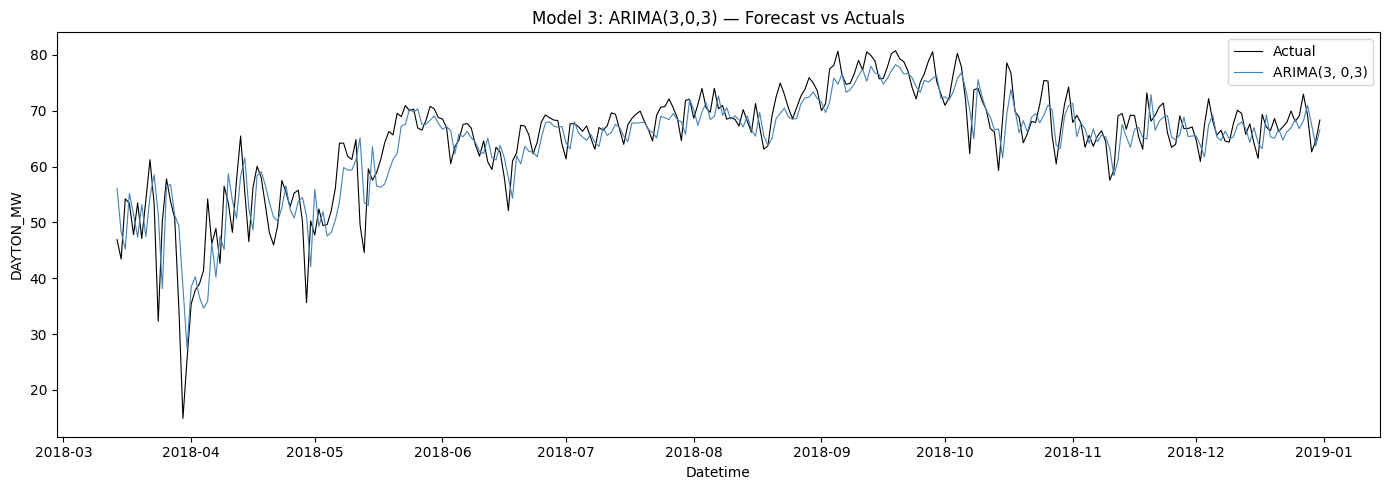

In [176]:

plt.figure(figsize=(14, 5))
plt.plot(test.index, test['price actual'], label="Actual", color="black",
         linewidth=0.8)
plt.plot(arima_preds.index, arima_preds,
         label=f"ARIMA({optimal_p}, {optimal_d},{optimal_q})",
         color="steelblue", linewidth=0.8)
plt.title(f"Model 3: ARIMA({optimal_p},{optimal_d},{optimal_q}) — Forecast vs Actuals")
plt.xlabel("Datetime")
plt.ylabel("DAYTON_MW")
plt.legend()
plt.tight_layout()
plt.show()